# Objectif du notebook 

Date de création : 12/01/2026

L'objectif du notebook est d'estimer la position associée à chacune des émissions de la source. Cette étape est nécessaire à la résolution du problème des moindres carrés pour l'inversion des positions des OBS. 

In [1]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")


In [3]:
sys.path.append(project_root)
from publication.publication_figure import PubFigure, color



# Chargement des temps d'émissions de la source pointés par Timothée M. 

In [4]:
fname = "emissions_source_12012026.xlsx"
fpath = os.path.join(root_groix_metadata, fname)

df_emission_src = pd.read_excel(fpath, sheet_name="Sheet1")

In [5]:
df_emission_src

,Date,Time UTC (non synchro),Point,Source,Longueur filée (m),Hydro distance (m),Signal,Frequency min (Hz),Frequency max (Hz),Duration (s),Nrepeat,Trepeat (s),Vc carte (V),Gain ampli,File,Initial samples,Initial timestamp UTC (synchro),Comment
0,2025-10-14,08:50:04,5,trailed,14,1.70,sinus,600,600,1,10,4,1.0,5,channelA_2025-10-14_08-50-04.wav,"[19272847, 19528847, 19784847, 20040847, 20296...",NaN,not seen on DAS
1,2025-10-14,08:50:04,5,trailed,14,1.70,chirp,100,1000,5,5,10,1.0,5,channelA_2025-10-14_08-50-04.wav,"[49962471, 50602471, 51242471, 51882471, 52522...",NaN,not seen on DAS
2,2025-10-14,08:50:04,5,trailed,14,1.70,chirp,100,1000,5,10,10,1.0,5,channelA_2025-10-14_08-50-04.wav,"[65466315, 66159101, 66857251, 67575906, 68308...",NaN,"not seen on DAS, warning repetitions not regular"
3,2025-10-14,09:21:08,5,trailed,14,1.70,sinus,600,600,5,10,10,2.0,5,channelA_2025-10-14_09-21-08.wav,"[25536251, 26176251, 26816251, 27456251, 28096...",NaN,NaN
4,2025-10-14,09:21:08,5,trailed,14,1.70,sinus,615,615,5,10,10,4.0,5,channelA_2025-10-14_09-21-08.wav,"[81033224, 81673224, 82313224, 82953224, 83593...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,2025-10-16,14:27:20,1S,fixed,8,1.35,sinus,625,625,5,10,10,4.0,5,channelA_2025-10-16_13-38-03.wav,"[187486816, 188126816, 188766816, 189406816, 1...",NaN,NaN
165,2025-10-16,14:29:04,1S,fixed,8,1.35,sinus,225,225,5,10,10,4.0,5,channelA_2025-10-16_13-38-03.wav,"[194092678, 194732678, 195372678, 196012678, 1...",NaN,NaN
166,2025-10-16,14:30:51,1S,fixed,8,1.35,sinus,125,125,5,10,10,4.0,5,channelA_2025-10-16_13-38-03.wav,"[200991168, 201631168, 202271168, 202911168, 2...",NaN,NaN
167,2025-10-16,14:33:19,1S,fixed,8,1.35,chirp,80,1000,5,10,10,4.0,5,channelA_2025-10-16_13-38-03.wav,"[210334594, 210974594, 211614594, 212254594, 2...",NaN,NaN


In [6]:
# # Form a datetime series from the Date and Time UTC columns --> Old version : first columns does not match the file start time 
# date = df_emission_src["Date"]
# time = df_emission_src["Time UTC (non synchro)"]
# # Datetime serie from date and time
# start_datetime = pd.to_datetime(date.astype(str) + " " + time.astype(str), format="%Y-%m-%d %H:%M:%S")

# Get start datetime from filename
datetime_str = df_emission_src["File"].str.split("_")
date_str = datetime_str.str[1]
time_str = datetime_str.str[2].str.split(".").str[0]
start_datetime = pd.to_datetime(date_str + " " + time_str, format="%Y-%m-%d %H-%M-%S")

# Store in the dataframe
df_emission_src["Datetime"] = start_datetime

In [7]:
start_datetime

0     2025-10-14 08:50:04
1     2025-10-14 08:50:04
2     2025-10-14 08:50:04
3     2025-10-14 09:21:08
4     2025-10-14 09:21:08
              ...        
164   2025-10-16 13:38:03
165   2025-10-16 13:38:03
166   2025-10-16 13:38:03
167   2025-10-16 13:38:03
168   2025-10-16 13:38:03
Name: File, Length: 169, dtype: datetime64[ns]

In [8]:
usefull_props = df_emission_src.columns.tolist()[2:-4]  # Exclude first two and last four columns
# usefull_props.remove("Nrepeat")  # Remove Nrepeat
usefull_props.extend(["Datetime"])  # Add Datetime

usefull_data = {prop: [] for prop in usefull_props}
usefull_data["Start sample"] = []
usefull_data["Sequence_id"] = []

# Loop over each line in the emission source dataframe
for idx in df_emission_src.index:
    line = df_emission_src.loc[idx]

    # Get number of single emissions
    apriori_n_single_emissions = line["Nrepeat"]

    # Store initial samples
    init_samp = line["Initial samples"]
    if isinstance(init_samp, str):
        init_samp = init_samp.split("[")[1].split("]")[0] # Remove opening and closing bracket 
        init_samp = [int(s.strip()) for s in init_samp.split(",")]      # Transform into int list
        # Update number of single emissions
        n_single_emissions = len(init_samp)     # Number of detected emissions

        # if len(init_samp) != n_single_emissions:
        #     print(idx, len(init_samp), n_single_emissions)
    elif isinstance(init_samp, float) and np.isnan(init_samp):
        # print(idx, line)
        init_samp = [np.nan] * apriori_n_single_emissions       # If the line is empty we use apriori number of emissions
    else:
        print(f"Error reading line {idx}")
        break

    # Store all usefull informations
    for prop in usefull_props:
        usefull_data[prop].extend([line[prop]] * n_single_emissions)

    # Add sequence id = each series of emissions = one line in the original dataframe
    usefull_data["Sequence_id"].extend([idx] * n_single_emissions)

    # Add emission initial samples
    usefull_data["Start sample"].extend(
        init_samp
    )


# print(init_samp)

props_dtype = {
    "Point": str,
    "Source": str,
    "Signal": str,
    "File": str,
    "Longueur filée (m)": str,  # Line with "ascending to 2m"
    "Hydro distance (m)": np.float32,
    "Frequency min (Hz)": np.float32,
    "Frequency max (Hz)": np.float32,
    "Duration (s)": np.float32,
    "Trepeat (s)": np.float32,
    "Nrepeat": int,
    "Vc carte (V)": np.float32,
    "Gain ampli": np.float32,
}

# Convert each property to the correct dtype
for prop in usefull_data.keys():
    usefull_data[prop] = pd.Series(usefull_data[prop], dtype=props_dtype.get(prop, object))

# Create final dataframe
df = pd.DataFrame(usefull_data)
# Convert Datetime back to datetime
df["Datetime"] = pd.to_datetime(df["Datetime"])
# Rename Datetime column for clarity
df = df.rename(columns={"Datetime": "File start datetime"})

# Drop lines with nan in Start sample
df = df.dropna(subset=["Start sample"]).reset_index(drop=True)

In [9]:
df

,Point,Source,Longueur filée (m),Hydro distance (m),Signal,Frequency min (Hz),Frequency max (Hz),Duration (s),Nrepeat,Trepeat (s),Vc carte (V),Gain ampli,File,File start datetime,Start sample,Sequence_id
0,5,trailed,14,1.70,sinus,600.0,600.0,1.0,10,4.0,1.0,5.0,channelA_2025-10-14_08-50-04.wav,2025-10-14 08:50:04,19272847,0
1,5,trailed,14,1.70,sinus,600.0,600.0,1.0,10,4.0,1.0,5.0,channelA_2025-10-14_08-50-04.wav,2025-10-14 08:50:04,19528847,0
2,5,trailed,14,1.70,sinus,600.0,600.0,1.0,10,4.0,1.0,5.0,channelA_2025-10-14_08-50-04.wav,2025-10-14 08:50:04,19784847,0
3,5,trailed,14,1.70,sinus,600.0,600.0,1.0,10,4.0,1.0,5.0,channelA_2025-10-14_08-50-04.wav,2025-10-14 08:50:04,20040847,0
4,5,trailed,14,1.70,sinus,600.0,600.0,1.0,10,4.0,1.0,5.0,channelA_2025-10-14_08-50-04.wav,2025-10-14 08:50:04,20296847,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2707,1S,fixed,8,1.35,chirp,80.0,1000.0,1.0,120,2.0,4.0,5.0,channelA_2025-10-16_13-38-03.wav,2025-10-16 13:38:03,265029324,168
2708,1S,fixed,8,1.35,chirp,80.0,1000.0,1.0,120,2.0,4.0,5.0,channelA_2025-10-16_13-38-03.wav,2025-10-16 13:38:03,265157324,168
2709,1S,fixed,8,1.35,chirp,80.0,1000.0,1.0,120,2.0,4.0,5.0,channelA_2025-10-16_13-38-03.wav,2025-10-16 13:38:03,265285324,168
2710,1S,fixed,8,1.35,chirp,80.0,1000.0,1.0,120,2.0,4.0,5.0,channelA_2025-10-16_13-38-03.wav,2025-10-16 13:38:03,265413324,168


In [10]:
df.columns

Index(['Point', 'Source', 'Longueur filée (m)', 'Hydro distance (m)', 'Signal',
       'Frequency min (Hz)', 'Frequency max (Hz)', 'Duration (s)', 'Nrepeat',
       'Trepeat (s)', 'Vc carte (V)', 'Gain ampli', 'File',
       'File start datetime', 'Start sample', 'Sequence_id'],
      dtype='object')

In [12]:
print(df.loc[df["Sequence_id"] == 168])

     Point Source Longueur filée (m)  Hydro distance (m) Signal  \
2688    1S  fixed                  8                1.35  chirp   
2689    1S  fixed                  8                1.35  chirp   
2690    1S  fixed                  8                1.35  chirp   
2691    1S  fixed                  8                1.35  chirp   
2692    1S  fixed                  8                1.35  chirp   
2693    1S  fixed                  8                1.35  chirp   
2694    1S  fixed                  8                1.35  chirp   
2695    1S  fixed                  8                1.35  chirp   
2696    1S  fixed                  8                1.35  chirp   
2697    1S  fixed                  8                1.35  chirp   
2698    1S  fixed                  8                1.35  chirp   
2699    1S  fixed                  8                1.35  chirp   
2700    1S  fixed                  8                1.35  chirp   
2701    1S  fixed                  8                1.35  chir

In [13]:
# Convert Start sample into UTC time
fs = 64000 # D'après le rapport de campagne 
Ts = 1 / fs

start_delta_time = df["Start sample"] * Ts  # in seconds
start_time_utc = df["File start datetime"] + pd.to_timedelta(start_delta_time, unit="s")
df["Emission datetime"] = start_time_utc

In [14]:
sec_from_start = Ts * 262597324
print(sec_from_start / 60)


68.38471979166667


#### Correction du décallage de la base de temps UTC de l'hydro source à partir des données Fosina 

Attention, le fichier de Fosina semble contenir les temps d'émissions au début de chaque séquence mais également tout un tas d'autre temps. Il faut donc faire le tri... 

In [ ]:
fpath_fsc = os.path.join(root_groix_metadata, "emissions_utc_fsc_clean.csv")
df_fsc = pd.read_csv(fpath_fsc, header=0, usecols=[1, 2, 3], sep=",")

# Reset index
df_fsc.set_index("Record", inplace=True)
# Create datetime
fsc_dt_str = df_fsc["Date"] + " " +  df_fsc["Time"]
fsc_datetime = pd.to_datetime(fsc_dt_str, format="%Y-%m-%d %H:%M:%S.%f")

In [ ]:
only_positive_shift = False 

# Associate to shifted emmision datetimes
emission_dt_shift = []
neg_i = 0
# Iterate over sequences
# ids = [16, 46, 77]  # df["Sequence_id"].unique()
ids = df["Sequence_id"].unique()
for seq_id in ids:
    df_seq_i = df.loc[df["Sequence_id"] == seq_id]
    df_seq_i_start_dt = df_seq_i.iloc[0]["Emission datetime"]    # First pulse of the sequence 

    # Get the closest datetime in fsc file
    delta_dt = fsc_datetime - df_seq_i_start_dt
    
    if only_positive_shift:
        # we know the approximate shift : t_utc_fsc = t_utc_hydro_source + 28 s, we can take the closest one approaching from left
        positive_idx = np.where(delta_dt >= pd.Timedelta("0s"))[0]

        # Ensure at least one positive delta_dt exists
        if positive_idx.size > 0:
            closest_idx = positive_idx[delta_dt.iloc[positive_idx].argmin()]
            # Get shift
            shift_seq_i = delta_dt.iloc[closest_idx].total_seconds()
        else:
            shift_seq_i = np.nan

            print(f"Negative {seq_id} -> {df_seq_i_start_dt} not find")
            # print(df_seq_i)
            neg_i += 1
    
    else:
        closest_idx = np.abs(delta_dt).argmin()
        # Get shift
        shift_seq_i = delta_dt.iloc[closest_idx].total_seconds()


    print(
        f"{seq_id} -> fsc {fsc_datetime.iloc[closest_idx]}, hydro {df_seq_i_start_dt} -> delta {delta_dt.iloc[closest_idx].total_seconds()}"
    )
    # print(df_seq_i)

    # Check if estimated shift match with expected shift
    # expected_shift_min = 25
    # expected_shift_max = 30
    # if shift_seq_i < expected_shift_min or shift_seq_i > expected_shift_max:
    #     print(f"{seq_id} -> {df_seq_i_start_dt} not in range -> {shift_seq_i}")
    #     # Considered not valid -> set to nan
    #     shift_seq_i = np.nan

        # print(df_seq_i)

    # print(f"Seq {seq_id} -> shift = {shift_seq_i}s ")

    # Store
    n_seq_id = df_seq_i.shape[0]
    emission_dt_shift.extend([shift_seq_i] * n_seq_id)

# print(neg_i)

0 -> fsc 2025-10-14 08:55:33.029704, hydro 2025-10-14 08:55:05.138234375 -> delta 27.891469
1 -> fsc 2025-10-14 09:03:32.561737, hydro 2025-10-14 09:03:04.663609375 -> delta 27.898127
2 -> fsc 2025-10-14 09:07:34.811741, hydro 2025-10-14 09:07:06.911171875 -> delta 27.900569
3 -> fsc 2025-10-14 09:28:15.080000, hydro 2025-10-14 09:27:47.003921875 -> delta 28.076078
4 -> fsc 2025-10-14 09:42:42.194195, hydro 2025-10-14 09:42:14.144125 -> delta 28.05007
5 -> fsc 2025-10-14 09:54:47.194858, hydro 2025-10-14 09:54:19.092328125 -> delta 28.102529
6 -> fsc 2025-10-14 09:59:50.466493, hydro 2025-10-14 09:59:22.407593750 -> delta 28.058899
7 -> fsc 2025-10-15 07:35:48.586295, hydro 2025-10-15 07:35:19.597218750 -> delta 28.989076
8 -> fsc 2025-10-15 07:38:33.419374, hydro 2025-10-15 07:38:04.429453125 -> delta 28.98992
9 -> fsc 2025-10-15 07:40:51.671536, hydro 2025-10-15 07:40:22.681640625 -> delta 28.989895
10 -> fsc 2025-10-15 07:42:41.686997, hydro 2025-10-15 07:42:12.694468750 -> delta 28

In [ ]:
for seq_id in ids:
    df_seq_i = df.loc[df["Sequence_id"] == seq_id]
    df_seq_i_start_dt = df_seq_i.iloc[0][
        "Emission datetime"
    ]  # First pulse of the sequence

    start_s = df_seq_i.iloc[0]["Start sample"]
    start_dt = df_seq_i.iloc[0]["File start datetime"]

    print(
        f"{seq_id} -> {df_seq_i_start_dt}, {start_dt}, {start_s}, {pd.to_timedelta(start_s*Ts, unit='s')}, {start_dt+  pd.to_timedelta(start_s*Ts, unit='s')}"
    )

0 -> 2025-10-14 08:55:05.138234375, 2025-10-14 08:50:04, 19272847, 0 days 00:05:01.138234375, 2025-10-14 08:55:05.138234375
1 -> 2025-10-14 09:03:04.663609375, 2025-10-14 08:50:04, 49962471, 0 days 00:13:00.663609375, 2025-10-14 09:03:04.663609375
2 -> 2025-10-14 09:07:06.911171875, 2025-10-14 08:50:04, 65466315, 0 days 00:17:02.911171875, 2025-10-14 09:07:06.911171875
3 -> 2025-10-14 09:27:47.003921875, 2025-10-14 09:21:08, 25536251, 0 days 00:06:39.003921875, 2025-10-14 09:27:47.003921875
4 -> 2025-10-14 09:42:14.144125, 2025-10-14 09:21:08, 81033224, 0 days 00:21:06.144125, 2025-10-14 09:42:14.144125
5 -> 2025-10-14 09:54:19.092328125, 2025-10-14 09:21:08, 127429909, 0 days 00:33:11.092328125, 2025-10-14 09:54:19.092328125
6 -> 2025-10-14 09:59:22.407593750, 2025-10-14 09:21:08, 146842086, 0 days 00:38:14.407593750, 2025-10-14 09:59:22.407593750
7 -> 2025-10-15 07:35:19.597218750, 2025-10-15 07:30:08, 19942222, 0 days 00:05:11.597218750, 2025-10-15 07:35:19.597218750
8 -> 2025-10-15

Text(0, 0.5, 'Décalage temporel [s]')

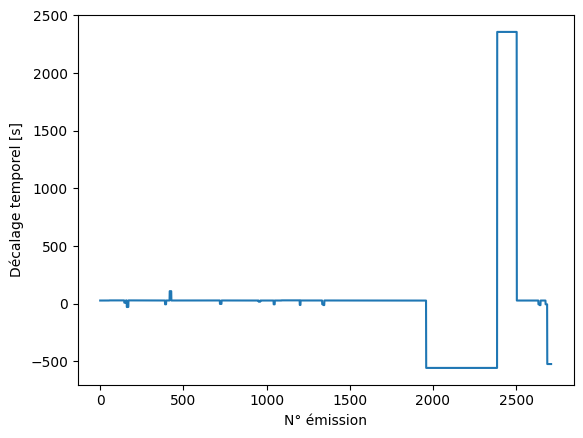

In [ ]:
plt.figure()
plt.plot(emission_dt_shift)
plt.xlabel("N° émission")
plt.ylabel("Décalage temporel [s]")

In [ ]:
# Store estimated shift
df["fsc_shift_s"] = emission_dt_shift

median_shift = np.round(df["fsc_shift_s"][0:1800].median(), 2)
print(f"Median shift = {median_shift}s")

Median shift = 27.97s


In [ ]:
# # Correct offset # TODO update with actual measured offset
# t_hydro_source_offset = 28.5
# t_hydro_source_offset = 0

# applied_time_shift = np.ones(df["Emission datetime"].size)
# applied_time_shift[:] = t_hydro_source_offset
applied_time_shift = median_shift

df["applied_time_shift_s"] = applied_time_shift
df["Emission datetime"] = df["Emission datetime"] + pd.Timedelta(
    applied_time_shift, "s"
)

In [ ]:
# df_subset = df[["Sequence_id", "File start datetime", "Emission datetime", "Start sample"]]
# df_subset = df
# df_subset = df_subset.loc[df_subset["Sequence_id"] == 42]
# print(df_subset)
# print(start_delta_time[df_subset.index])

In [ ]:
# Reorganize a bit for clarity : Emission datetime -> first column, Sequence_id -> second column
cols = df.columns.tolist()
cols_new_order = {
    "Emission datetime": 0,
    "Sequence_id": 1,
}
for col in cols_new_order.keys():
    cols.remove(col)
    cols.insert(cols_new_order[col], col)
df = df[cols].copy()


# Association des émissions à la position de la source 

In [ ]:
# Load datasets
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))
ds_ais = xr.open_dataset(os.path.join(data_folder, "ais.nc"))
ds_bathy = xr.open_dataset(os.path.join(data_folder, "bathy.nc"))

In [ ]:
# First approach : Nearest neighbor in time for GPS
gps_emission_time = ds_gps.sel(time=df["Emission datetime"].values, method="nearest")
# Add GPS info to the dataframe
df["Emission latitude GPS"] = gps_emission_time["lat"].values
df["Emission longitude GPS"] = gps_emission_time["lon"].values
df["Emission E GPS"] = gps_emission_time["e"].values
df["Emission N GPS"] = gps_emission_time["n"].values
df["Emission U GPS"] = gps_emission_time["u"].values

In [ ]:
# First approach : Nearest neighbor in time for GPS
mmsi_jules = 226916000
ds_ais = ds_ais.sel(mmsi=mmsi_jules)
ais_emission_time = ds_ais.sel(time=df["Emission datetime"].values, method="nearest")
# Add GPS info to the dataframe
df["Emission latitude AIS"] = ais_emission_time["lat"].values
df["Emission longitude AIS"] = ais_emission_time["lon"].values
df["Emission E AIS"] = ais_emission_time["e"].values
df["Emission N AIS"] = ais_emission_time["n"].values
df["Emission U AIS"] = ais_emission_time["u"].values

In [ ]:
df.columns

Index(['Emission datetime', 'Sequence_id', 'Point', 'Source',
       'Longueur filée (m)', 'Hydro distance (m)', 'Signal',
       'Frequency min (Hz)', 'Frequency max (Hz)', 'Duration (s)', 'Nrepeat',
       'Trepeat (s)', 'Vc carte (V)', 'Gain ampli', 'File',
       'File start datetime', 'Start sample', 'fsc_shift_s',
       'applied_time_shift_s', 'Emission latitude GPS',
       'Emission longitude GPS', 'Emission E GPS', 'Emission N GPS',
       'Emission U GPS', 'Emission latitude AIS', 'Emission longitude AIS',
       'Emission E AIS', 'Emission N AIS', 'Emission U AIS'],
      dtype='object')

In [ ]:
# Interp coords

# Third approach : Interpolation of ENU coords GPS
t0 = ds_gps.time.values[0]
gps_linear_time = (ds_gps.time - t0).values / np.timedelta64(1, "s")     # Linear time from start 
emission_linear_time = (df["Emission datetime"] - t0) / np.timedelta64(
    1, "s"
)  # Linear time from start
gps_emission_time_interp_e = np.interp(
    emission_linear_time.values, gps_linear_time, ds_gps.e.values
)
gps_emission_time_interp_n = np.interp(
    emission_linear_time.values, gps_linear_time, ds_gps.n.values
)
gps_emission_time_interp_u = np.interp(
    emission_linear_time.values, gps_linear_time, ds_gps.u.values
)
# Add GPS info to the dataframe
df["Emission interpolated E GPS"] = gps_emission_time_interp_e
df["Emission interpolated N GPS"] = gps_emission_time_interp_n
df["Emission interpolated U GPS"] = gps_emission_time_interp_u

# Forth approach : interpolation of ENU AIS
# mmsi_jules = 226916000
# ds_ais = ds_ais.sel(mmsi=mmsi_jules)

t0 = ds_ais.time.values[0]
ais_linear_time = (ds_ais.time - t0).values / np.timedelta64(
    1, "s"
)  # Linear time from start
ais_emission_time_interp_e = np.interp(
    emission_linear_time.values, ais_linear_time, ds_ais.e.values
)
ais_emission_time_interp_n = np.interp(
    emission_linear_time.values, ais_linear_time, ds_ais.n.values
)
ais_emission_time_interp_u = np.interp(
    emission_linear_time.values, ais_linear_time, ds_ais.u.values
)
# Add AIS info to the dataframe
df["Emission interpolated E AIS"] = ais_emission_time_interp_e
df["Emission interpolated N AIS"] = ais_emission_time_interp_n
df["Emission interpolated U AIS"] = ais_emission_time_interp_u

# Vitesse de la source à chaque émission

In [ ]:
# Interpolation of ENU speed (GPS)
t0 = ds_gps.time.values[0]
gps_linear_time = (ds_gps.time - t0).values / np.timedelta64(1, "s")     # Linear time from start 
emission_linear_time = (df["Emission datetime"] - t0) / np.timedelta64(
    1, "s"
)  # Linear time from start
gps_emission_time_interp_ve = np.interp(
    emission_linear_time.values, gps_linear_time, ds_gps.v_e.values
)
gps_emission_time_interp_vn = np.interp(
    emission_linear_time.values, gps_linear_time, ds_gps.v_n.values
)
gps_emission_time_interp_vu = np.interp(
    emission_linear_time.values, gps_linear_time, ds_gps.v_u.values
)
# Add GPS info to the dataframe
df["emission_interp_ve_gps"] = gps_emission_time_interp_ve
df["emission_interp_vn_gps"] = gps_emission_time_interp_vn
df["emission_interp_vu_gps"] = gps_emission_time_interp_vu

# Interpolation of ENU AIS
# mmsi_jules = 226916000
# ds_ais = ds_ais.sel(mmsi=mmsi_jules)

t0 = ds_ais.time.values[0]
ais_linear_time = (ds_ais.time - t0).values / np.timedelta64(
    1, "s"
)  # Linear time from start
ais_emission_time_interp_ve = np.interp(
    emission_linear_time.values, ais_linear_time, ds_ais.v_e.values
)
ais_emission_time_interp_vn = np.interp(
    emission_linear_time.values, ais_linear_time, ds_ais.v_n.values
)
ais_emission_time_interp_vu = np.interp(
    emission_linear_time.values, ais_linear_time, ds_ais.v_u.values
)
# Add AIS info to the dataframe
df["emission_interp_ve_ais"] = ais_emission_time_interp_ve
df["emission_interp_vn_ais"] = ais_emission_time_interp_vn
df["emission_interp_vu_ais"] = ais_emission_time_interp_vu

In [ ]:
# Rename all columns
name_mapper = {
    "Emission datetime": "emission_datetime",
    "Sequence_id": "sequence_id",
    "Point": "src_pos_point",
    "Source": "src_pos_status",
    "Longueur filée (m)": "deployed_length_m",
    "Hydro distance (m)": "hydrophone_distance_m",
    "Signal": "signal_type",
    "Frequency min (Hz)": "frequency_min_hz",
    "Frequency max (Hz)": "frequency_max_hz",
    "Duration (s)": "duration_s",
    "Nrepeat": "num_repetitions",
    "Trepeat (s)": "repeat_period_s",
    "Vc carte (V)": "board_voltage_v",
    "Gain ampli": "amplifier_gain",
    "File": "file_name",
    "File start datetime": "file_start_datetime",
    "Start sample": "start_sample",
    "fsc_shift_s": "fsc_shift_s",
    "Emission latitude GPS": "emission_latitude_gps",
    "Emission longitude GPS": "emission_longitude_gps",
    "Emission E GPS": "emission_e_gps",
    "Emission N GPS": "emission_n_gps",
    "Emission U GPS": "emission_u_gps",
    "Emission latitude AIS": "emission_latitude_ais",
    "Emission longitude AIS": "emission_longitude_ais",
    "Emission E AIS": "emission_e_ais",
    "Emission N AIS": "emission_n_ais",
    "Emission U AIS": "emission_u_ais",
    "Emission interpolated E GPS": "emission_interp_e_gps",
    "Emission interpolated N GPS": "emission_interp_n_gps",
    "Emission interpolated U GPS": "emission_interp_u_gps",
    "Emission interpolated E AIS": "emission_interp_e_ais",
    "Emission interpolated N AIS": "emission_interp_n_ais",
    "Emission interpolated U AIS": "emission_interp_u_ais",
}
df.rename(columns=name_mapper, inplace=True)

In [ ]:
df.columns

Index(['emission_datetime', 'sequence_id', 'src_pos_point', 'src_pos_status',
       'deployed_length_m', 'hydrophone_distance_m', 'signal_type',
       'frequency_min_hz', 'frequency_max_hz', 'duration_s', 'num_repetitions',
       'repeat_period_s', 'board_voltage_v', 'amplifier_gain', 'file_name',
       'file_start_datetime', 'start_sample', 'fsc_shift_s',
       'applied_time_shift_s', 'emission_latitude_gps',
       'emission_longitude_gps', 'emission_e_gps', 'emission_n_gps',
       'emission_u_gps', 'emission_latitude_ais', 'emission_longitude_ais',
       'emission_e_ais', 'emission_n_ais', 'emission_u_ais',
       'emission_interp_e_gps', 'emission_interp_n_gps',
       'emission_interp_u_gps', 'emission_interp_e_ais',
       'emission_interp_n_ais', 'emission_interp_u_ais',
       'emission_interp_ve_gps', 'emission_interp_vn_gps',
       'emission_interp_vu_gps', 'emission_interp_ve_ais',
       'emission_interp_vn_ais', 'emission_interp_vu_ais'],
      dtype='object')

In [ ]:
df

,emission_datetime,sequence_id,src_pos_point,src_pos_status,deployed_length_m,hydrophone_distance_m,signal_type,frequency_min_hz,frequency_max_hz,duration_s,...,emission_interp_u_gps,emission_interp_e_ais,emission_interp_n_ais,emission_interp_u_ais,emission_interp_ve_gps,emission_interp_vn_gps,emission_interp_vu_gps,emission_interp_ve_ais,emission_interp_vn_ais,emission_interp_vu_ais
0,2025-10-14 08:55:33.108234375,0,5,trailed,14,1.70,sinus,600.0,600.0,1.0,...,30.471753,2924.583920,-461.555559,30.474612,-1.163551,0.743654,0.000588,-0.869874,0.427890,0.000429
1,2025-10-14 08:55:37.108234375,0,5,trailed,14,1.70,sinus,600.0,600.0,1.0,...,30.474968,2921.676478,-460.033789,30.476052,-1.233151,0.745102,0.000619,-1.053918,0.488950,0.000516
2,2025-10-14 08:55:41.108234375,0,5,trailed,14,1.70,sinus,600.0,600.0,1.0,...,30.477823,2917.749215,-458.173675,30.477979,-1.248909,0.718853,0.000623,-1.197686,0.528929,0.000584
3,2025-10-14 08:55:45.108234375,0,5,trailed,14,1.70,sinus,600.0,600.0,1.0,...,30.479740,2911.160886,-455.430703,30.481177,-1.124180,0.620332,0.000558,-1.236358,0.513901,0.000600
4,2025-10-14 08:55:49.108234375,0,5,trailed,14,1.70,sinus,600.0,600.0,1.0,...,30.481657,2904.572556,-452.687730,30.484375,-0.999451,0.521811,0.000493,-1.275030,0.498872,0.000616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2707,2025-10-16 14:47:32.053187500,168,1S,fixed,8,1.35,chirp,80.0,1000.0,1.0,...,30.720633,-811.417761,-815.906089,30.718840,-0.600931,-0.243395,0.000387,-0.463836,-0.224460,0.000405
2708,2025-10-16 14:47:34.053187500,168,1S,fixed,8,1.35,chirp,80.0,1000.0,1.0,...,30.720420,-812.274100,-816.317353,30.718679,-0.600931,-0.243395,0.000867,-0.498578,-0.242801,0.000878
2709,2025-10-16 14:47:36.053187500,168,1S,fixed,8,1.35,chirp,80.0,1000.0,1.0,...,30.720208,-813.130440,-816.728617,30.718517,-0.600931,-0.243395,0.001346,-0.533320,-0.261142,0.001351
2710,2025-10-16 14:47:38.053187500,168,1S,fixed,8,1.35,chirp,80.0,1000.0,1.0,...,30.719995,-813.986779,-817.139881,30.718355,-0.600931,-0.243395,0.001826,-0.568063,-0.279482,0.001824


Text(0, 0.5, 'Latitude [°]')

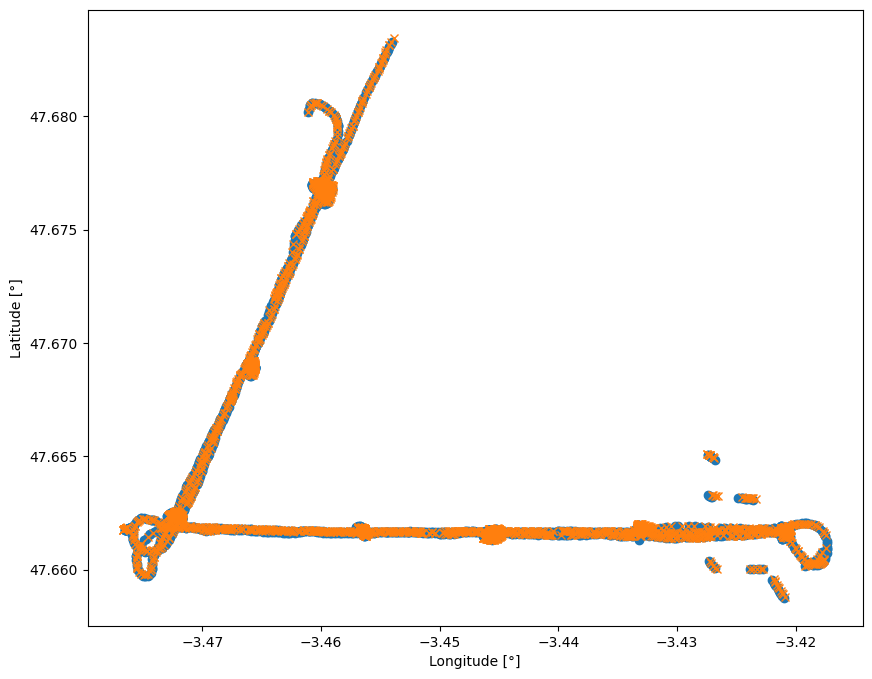

In [ ]:
# Plot
plt.figure(figsize=(10, 8))
plt.plot(
    df["emission_longitude_gps"],
    df["emission_latitude_gps"],
    "o",
    label="GPS Emission positions",
)
plt.plot(
    df["emission_longitude_ais"],
    df["emission_latitude_ais"],
    "x",
    label="AIS Emission positions",
)
plt.xlabel("Longitude [°]")
plt.ylabel("Latitude [°]")

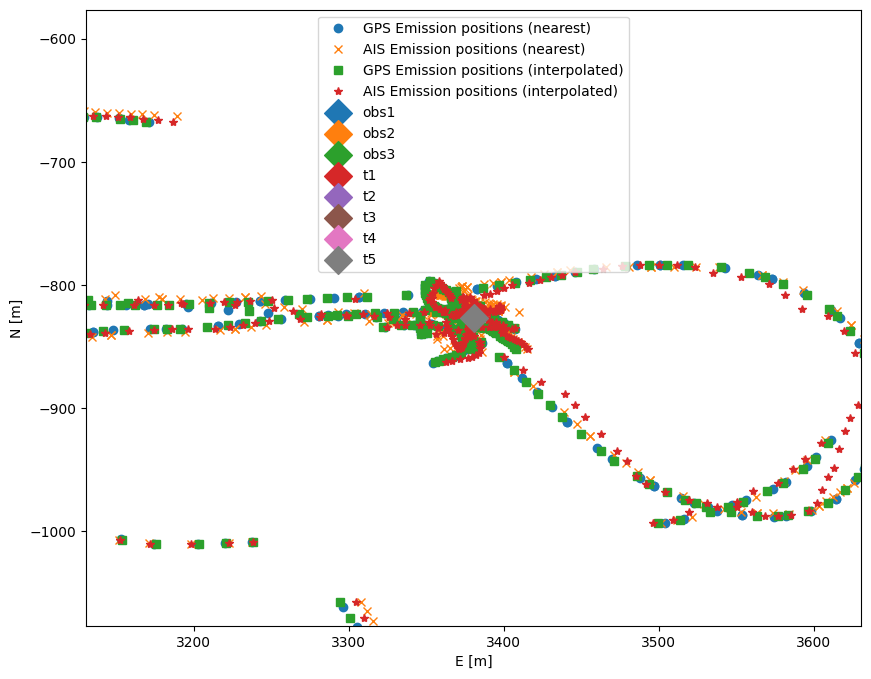

In [ ]:
# Plot
plt.figure(figsize=(10, 8))
plt.plot(
    df["emission_e_gps"],
    df["emission_n_gps"],
    "o",
    label="GPS Emission positions (nearest)",
)
plt.plot(
    df["emission_e_ais"],
    df["emission_n_ais"],
    "x",
    label="AIS Emission positions (nearest)",
)
plt.plot(
    df["emission_interp_e_gps"],
    df["emission_interp_n_gps"],
    "s",
    label="GPS Emission positions (interpolated)",
)
plt.plot(
    df["emission_interp_e_ais"],
    df["emission_interp_n_gps"],
    "*",
    label="AIS Emission positions (interpolated)",
)
plt.xlabel("E [m]")
plt.ylabel("N [m]")

keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
for k in keys:
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    plt.scatter(
        e,
        n,
        marker="D",
        label=k,
        zorder=10,
        s=200,
    )

# ZOOM on one position
de = 500
dn = 500
src_pos_id = "t5"
plt.xlim(
    ds_gps.attrs[f"{src_pos_id}_e_apriori"] - de / 2,
    ds_gps.attrs[f"{src_pos_id}_e_apriori"] + de / 2,
)
plt.ylim(
    ds_gps.attrs[f"{src_pos_id}_n_apriori"] - dn / 2,
    ds_gps.attrs[f"{src_pos_id}_n_apriori"] + dn / 2,
)


plt.legend()

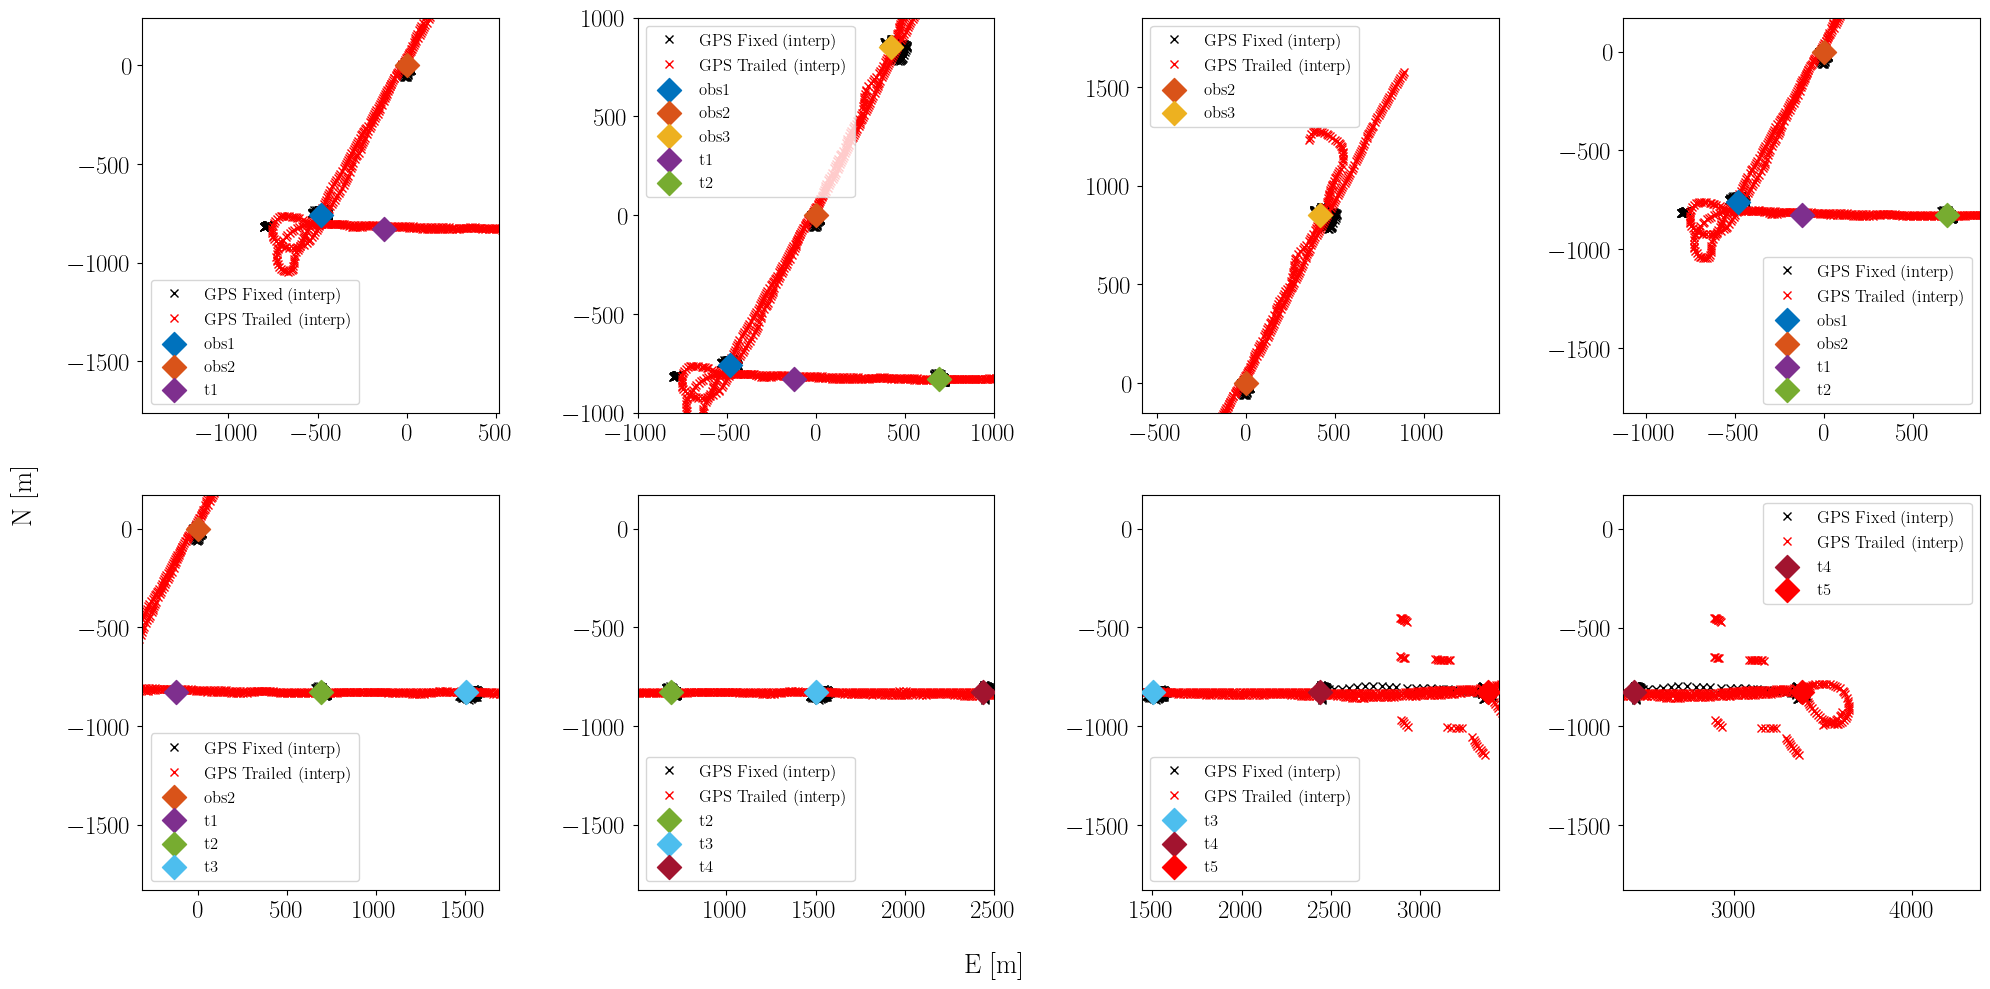

In [ ]:
# Plot
pfig = PubFigure(ticks_fontsize=18, label_fontsize=20, legend_fontsize=12)
de = 2000
dn = 2000

# day = datetime(2025, 10, 14)
# df_sel = df[df["Emission datetime"] == day]
pos_of_interest = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]


fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(20, 10), sharex=False, sharey=False)
for ipos, pos in enumerate(pos_of_interest):
    i = ipos // 4
    j = ipos % 4
    ax = axs[i, j]

    # Choose color base on the type of emission (fixed or trailed)
    mask_trailed = df["src_pos_status"].str.fullmatch("trailed")
    mask_fixed = df["src_pos_status"].str.fullmatch("fixed")
    ax.plot(
        df["emission_interp_e_gps"][mask_fixed],
        df["emission_interp_n_gps"][mask_fixed],
        "x",
        label="GPS Fixed (interp)",
        color="k",
    )
    ax.plot(
        df["emission_interp_e_gps"][mask_trailed],
        df["emission_interp_n_gps"][mask_trailed],
        "x",
        label="GPS Trailed (interp)",
        color="r",
    )

    e_pos = ds_gps.attrs[f"{pos}_e_apriori"]
    n_pos = ds_gps.attrs[f"{pos}_n_apriori"]
    for ik, k in enumerate(pos_of_interest):
        e_pos_k = ds_gps.attrs[f"{k}_e_apriori"]
        n_pos_k = ds_gps.attrs[f"{k}_n_apriori"]
        if np.abs(e_pos_k - e_pos) <= de/2 and np.abs(n_pos_k - n_pos) < dn/2:
            # print(f"Plotting {k} in pos {pos}: {e_pos_k}, {n_pos_k}")
            ax.scatter(
                e_pos_k,
                n_pos_k,
                marker="D",
                label=k,
                zorder=10,
                s=150,
                color=color(ik),
            )
    ax.set_xlim([e_pos-de/2, e_pos+de/2])
    ax.set_ylim([n_pos-dn/2, n_pos+dn/2])

    ax.set_xlabel("")  
    ax.set_ylabel("")
    ax.legend()

fig.supxlabel("E [m]")
fig.supylabel("N [m]")

# Save figure
fig_fpath = os.path.join(img_folder, "emission", "emission_positions.png")
plt.savefig(fig_fpath, dpi=300)

In [ ]:
df.columns

Index(['emission_datetime', 'sequence_id', 'src_pos_point', 'src_pos_status',
       'deployed_length_m', 'hydrophone_distance_m', 'signal_type',
       'frequency_min_hz', 'frequency_max_hz', 'duration_s', 'num_repetitions',
       'repeat_period_s', 'board_voltage_v', 'amplifier_gain', 'file_name',
       'file_start_datetime', 'start_sample', 'fsc_shift_s',
       'applied_time_shift_s', 'emission_latitude_gps',
       'emission_longitude_gps', 'emission_e_gps', 'emission_n_gps',
       'emission_u_gps', 'emission_latitude_ais', 'emission_longitude_ais',
       'emission_e_ais', 'emission_n_ais', 'emission_u_ais',
       'emission_interp_e_gps', 'emission_interp_n_gps',
       'emission_interp_u_gps', 'emission_interp_e_ais',
       'emission_interp_n_ais', 'emission_interp_u_ais',
       'emission_interp_ve_gps', 'emission_interp_vn_gps',
       'emission_interp_vu_gps', 'emission_interp_ve_ais',
       'emission_interp_vn_ais', 'emission_interp_vu_ais'],
      dtype='object')

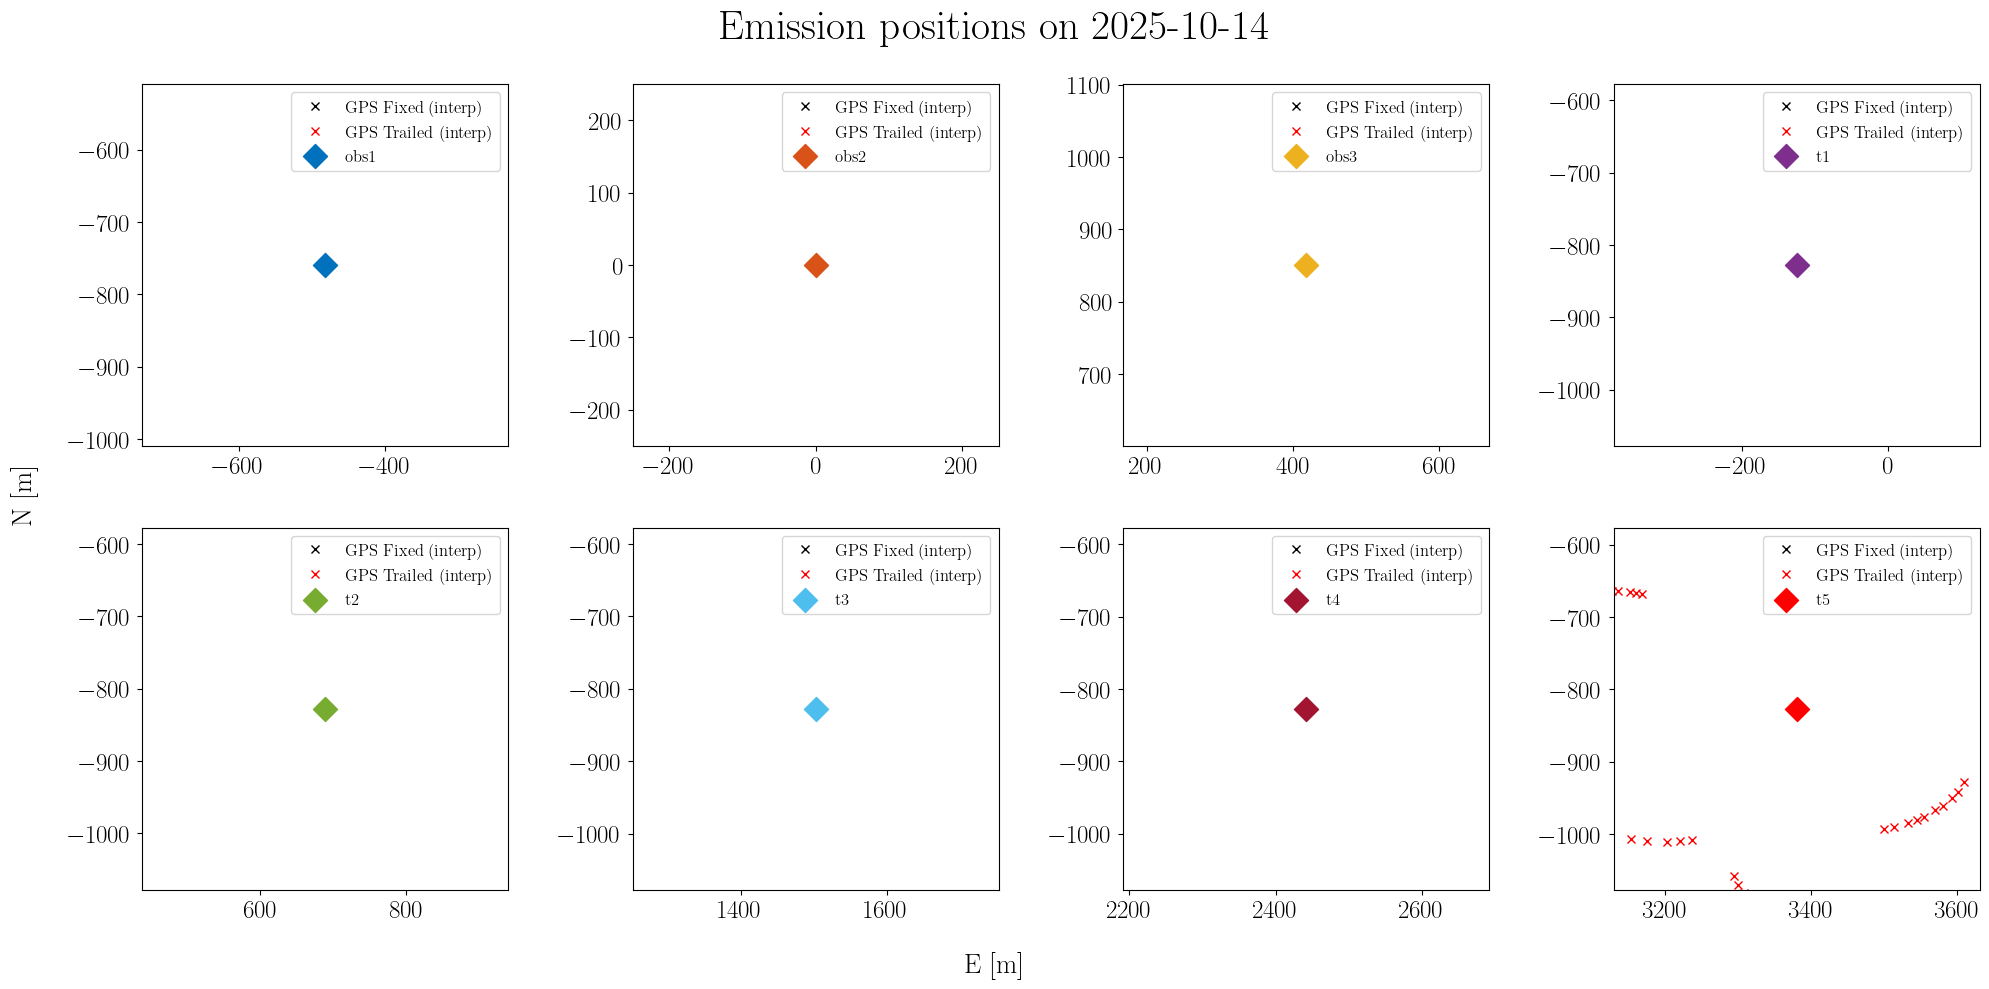

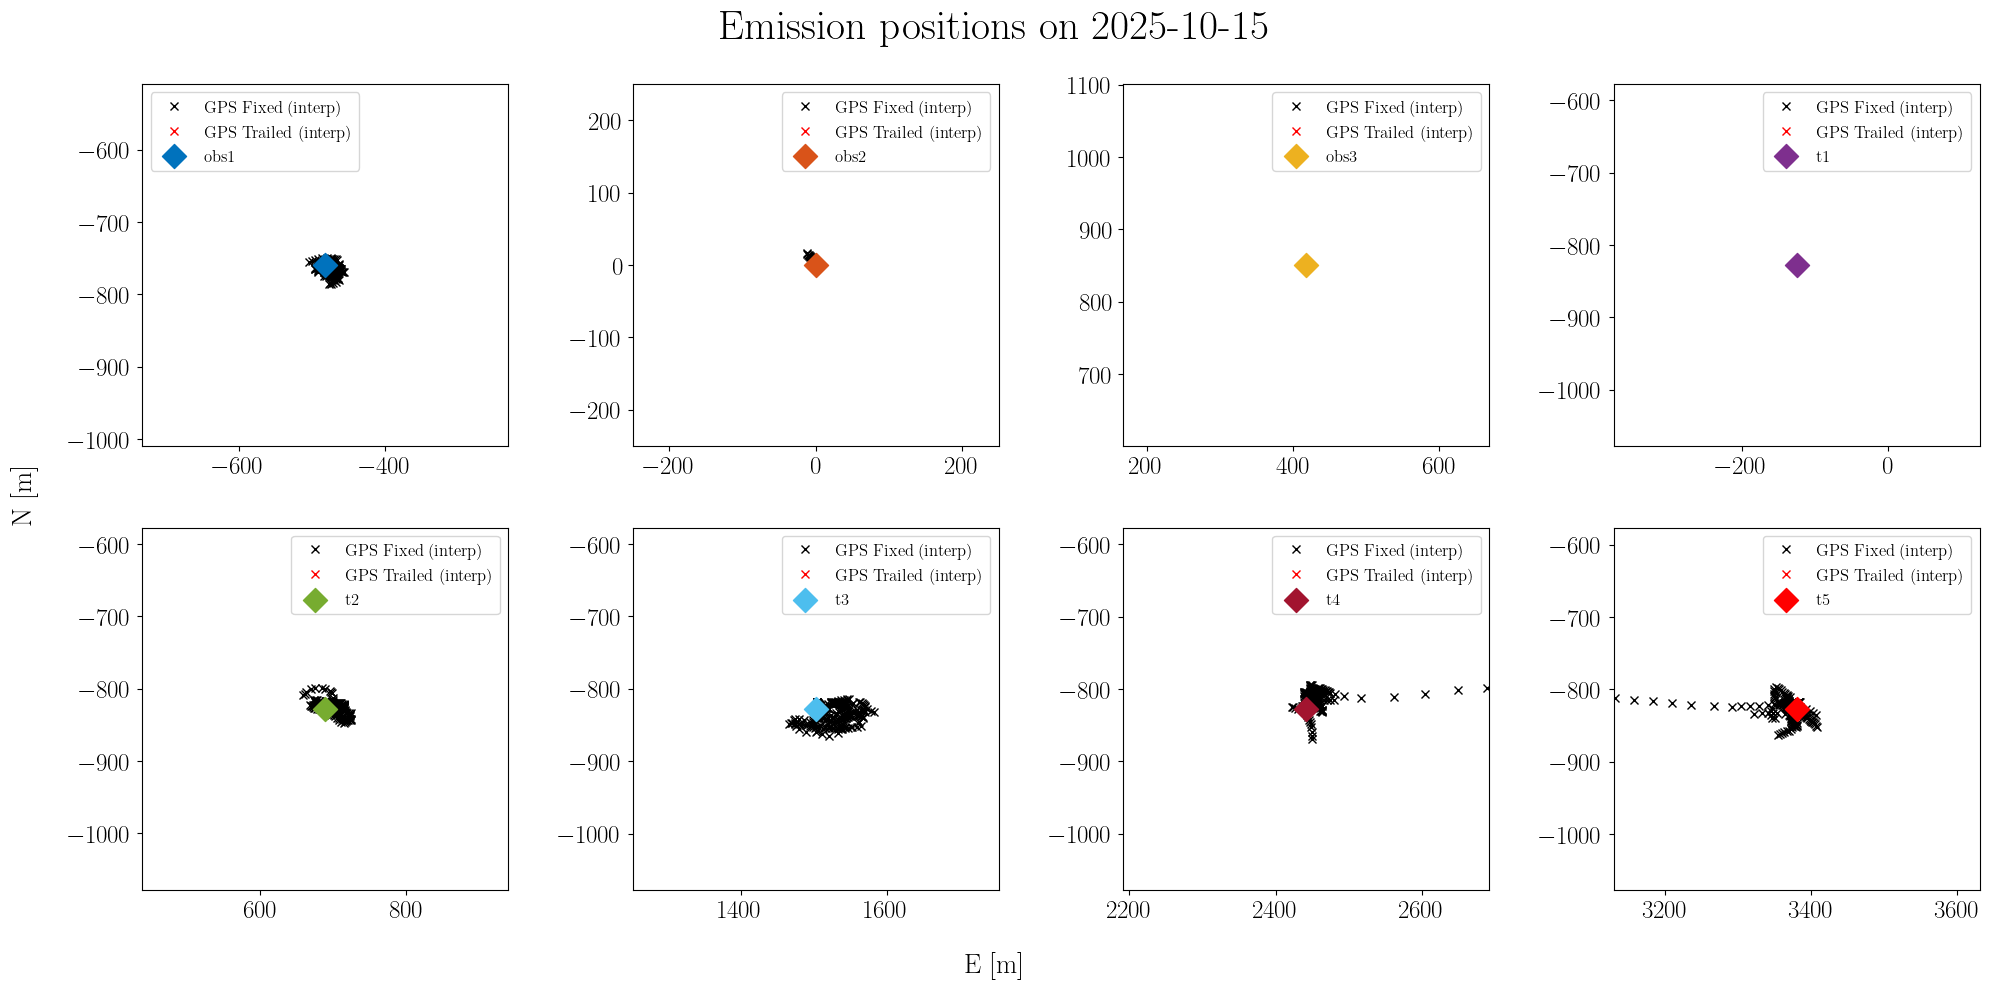

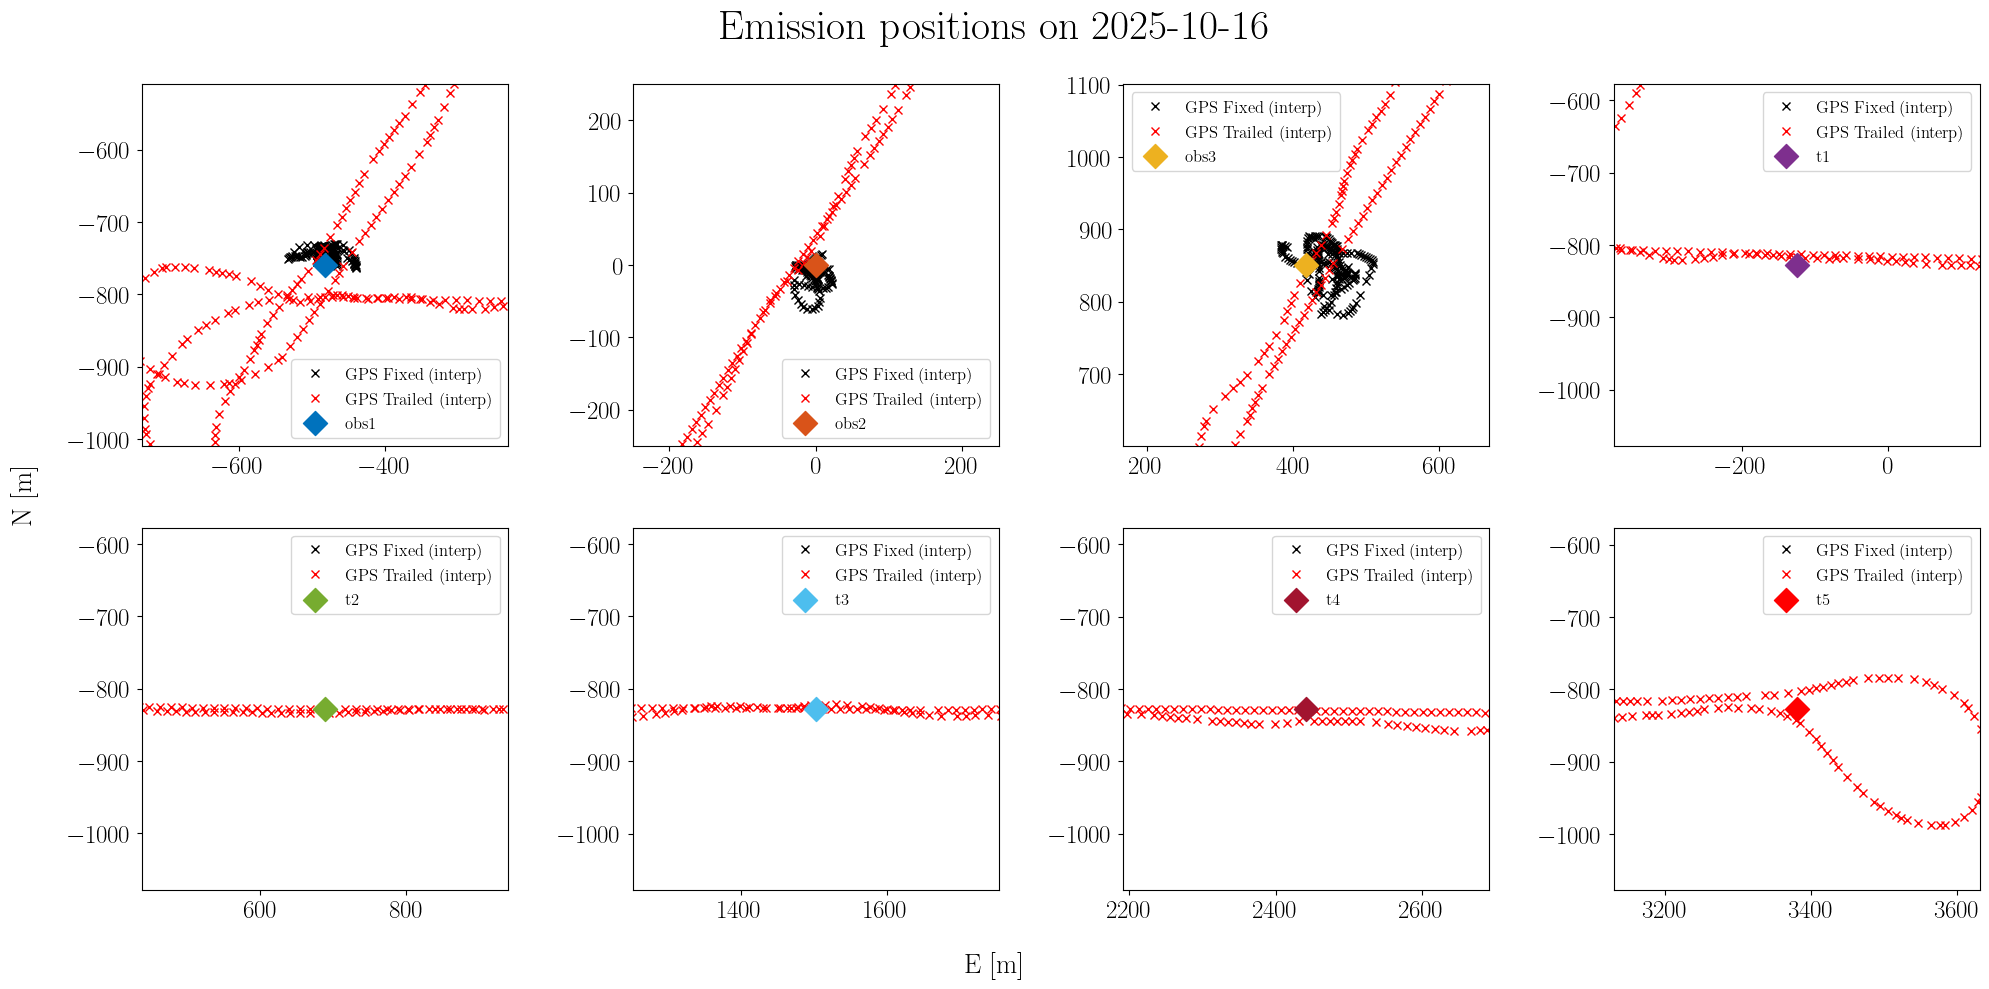

In [ ]:
# Analyse each day serapately

# Plot
pfig = PubFigure(ticks_fontsize=18, label_fontsize=20, legend_fontsize=12)
de = 500
dn = 500

pos_of_interest = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]

days = df["emission_datetime"].dt.date.unique()
for day in days:

    df_sel = df[df["emission_datetime"].dt.date == day]

    fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(20, 10), sharex=False, sharey=False)
    for ipos, pos in enumerate(pos_of_interest):
        i = ipos // 4
        j = ipos % 4
        ax = axs[i, j]

        # Choose color base on the type of emission (fixed or trailed)
        mask_trailed = df["src_pos_status"].str.fullmatch("trailed")
        mask_fixed = df["src_pos_status"].str.fullmatch("fixed")
        ax.plot(
            df_sel["emission_interp_e_gps"][mask_fixed],
            df_sel["emission_interp_n_gps"][mask_fixed],
            "x",
            label="GPS Fixed (interp)",
            color="k",
        )
        ax.plot(
            df_sel["emission_interp_e_gps"][mask_trailed],
            df_sel["emission_interp_n_gps"][mask_trailed],
            "x",
            label="GPS Trailed (interp)",
            color="r",
        )

        e_pos = ds_gps.attrs[f"{pos}_e_apriori"]
        n_pos = ds_gps.attrs[f"{pos}_n_apriori"]
        for ik, k in enumerate(pos_of_interest):
            e_pos_k = ds_gps.attrs[f"{k}_e_apriori"]
            n_pos_k = ds_gps.attrs[f"{k}_n_apriori"]
            if np.abs(e_pos_k - e_pos) <= de/2 and np.abs(n_pos_k - n_pos) < dn/2:
                # print(f"Plotting {k} in pos {pos}: {e_pos_k}, {n_pos_k}")
                ax.scatter(
                    e_pos_k,
                    n_pos_k,
                    marker="D",
                    label=k,
                    zorder=10,
                    s=150,
                    color=color(ik),
                )
        ax.set_xlim([e_pos-de/2, e_pos+de/2])
        ax.set_ylim([n_pos-dn/2, n_pos+dn/2])

        ax.set_xlabel("")  
        ax.set_ylabel("")
        ax.legend()

    fig.supxlabel("E [m]")
    fig.supylabel("N [m]")

    fig.suptitle(f"Emission positions on {day.strftime('%Y-%m-%d')}")

    # Save figure
    fig_fpath = os.path.join(
        img_folder, "emission", f"emission_positions_{day.strftime('%Y_%m_%d')}.png"
    )
    plt.savefig(fig_fpath, dpi=300)

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\matplotlib\quiver.py:678: RuntimeWarning: Mean of empty slice
  amean = a.mean()
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


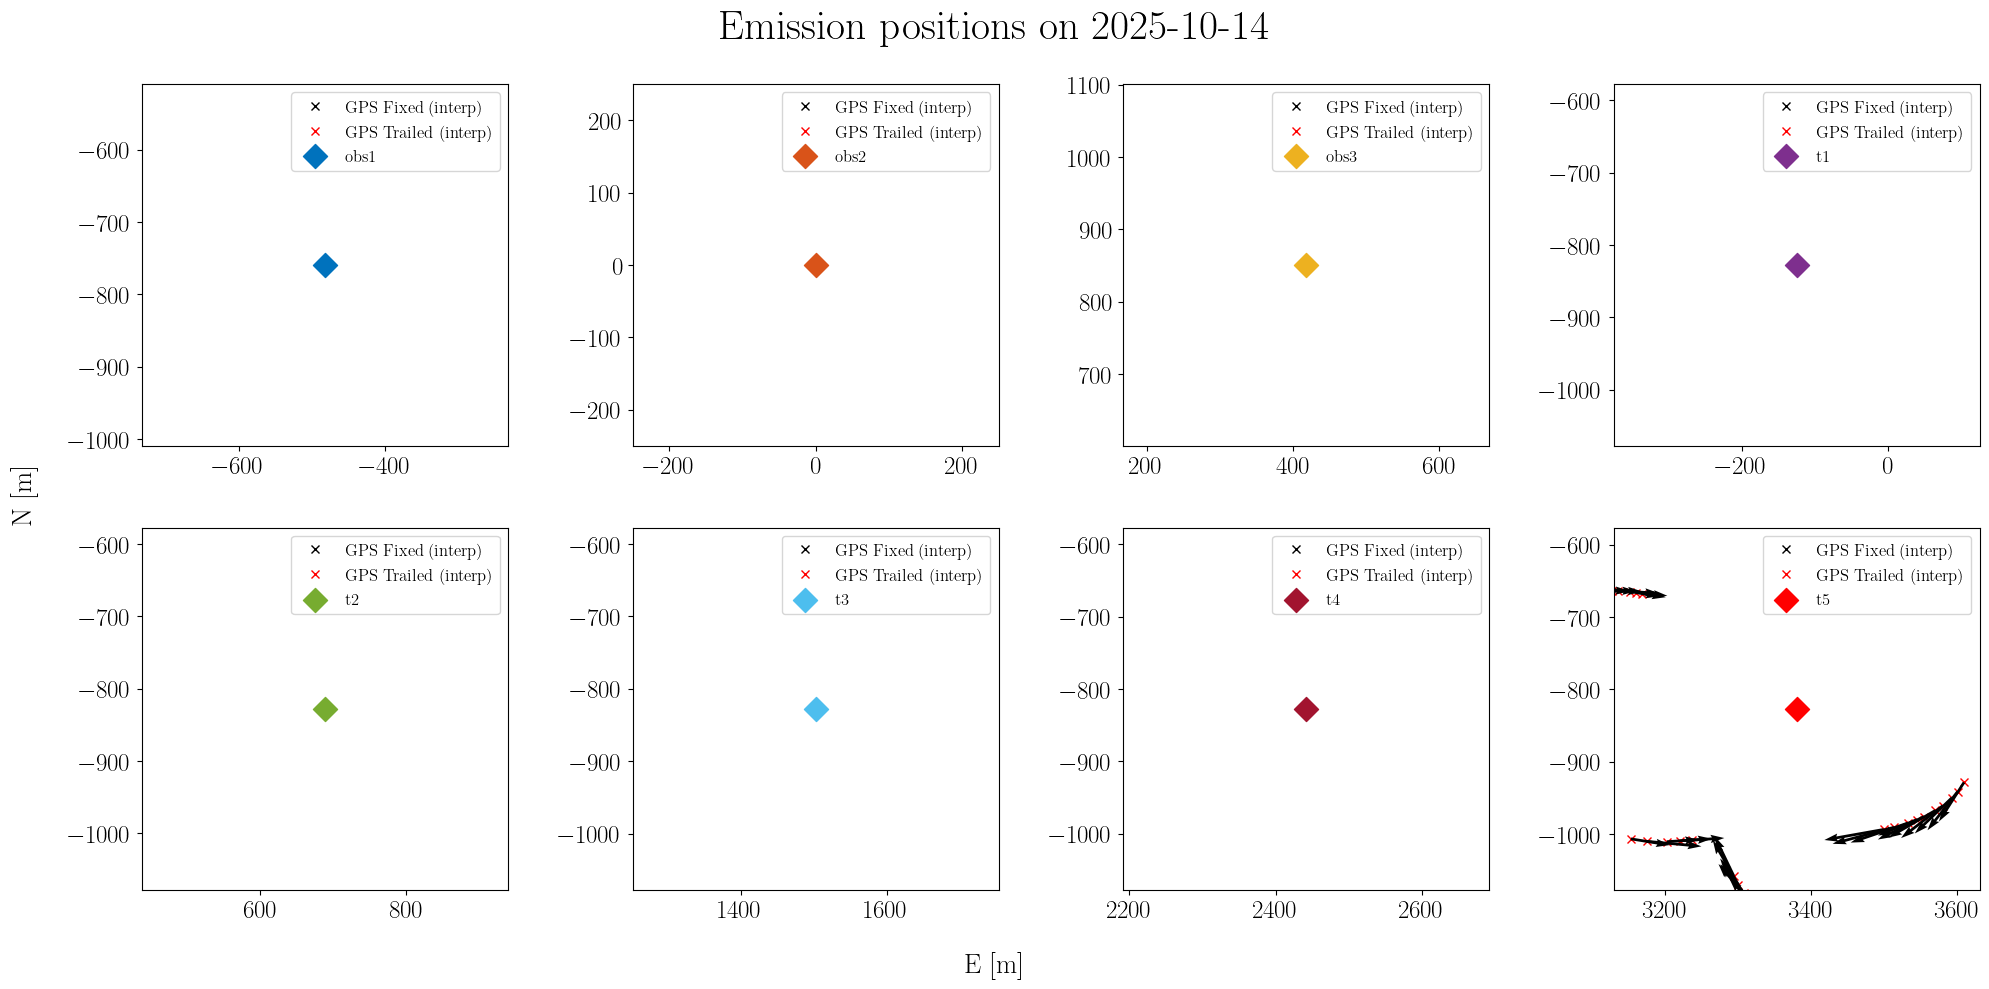

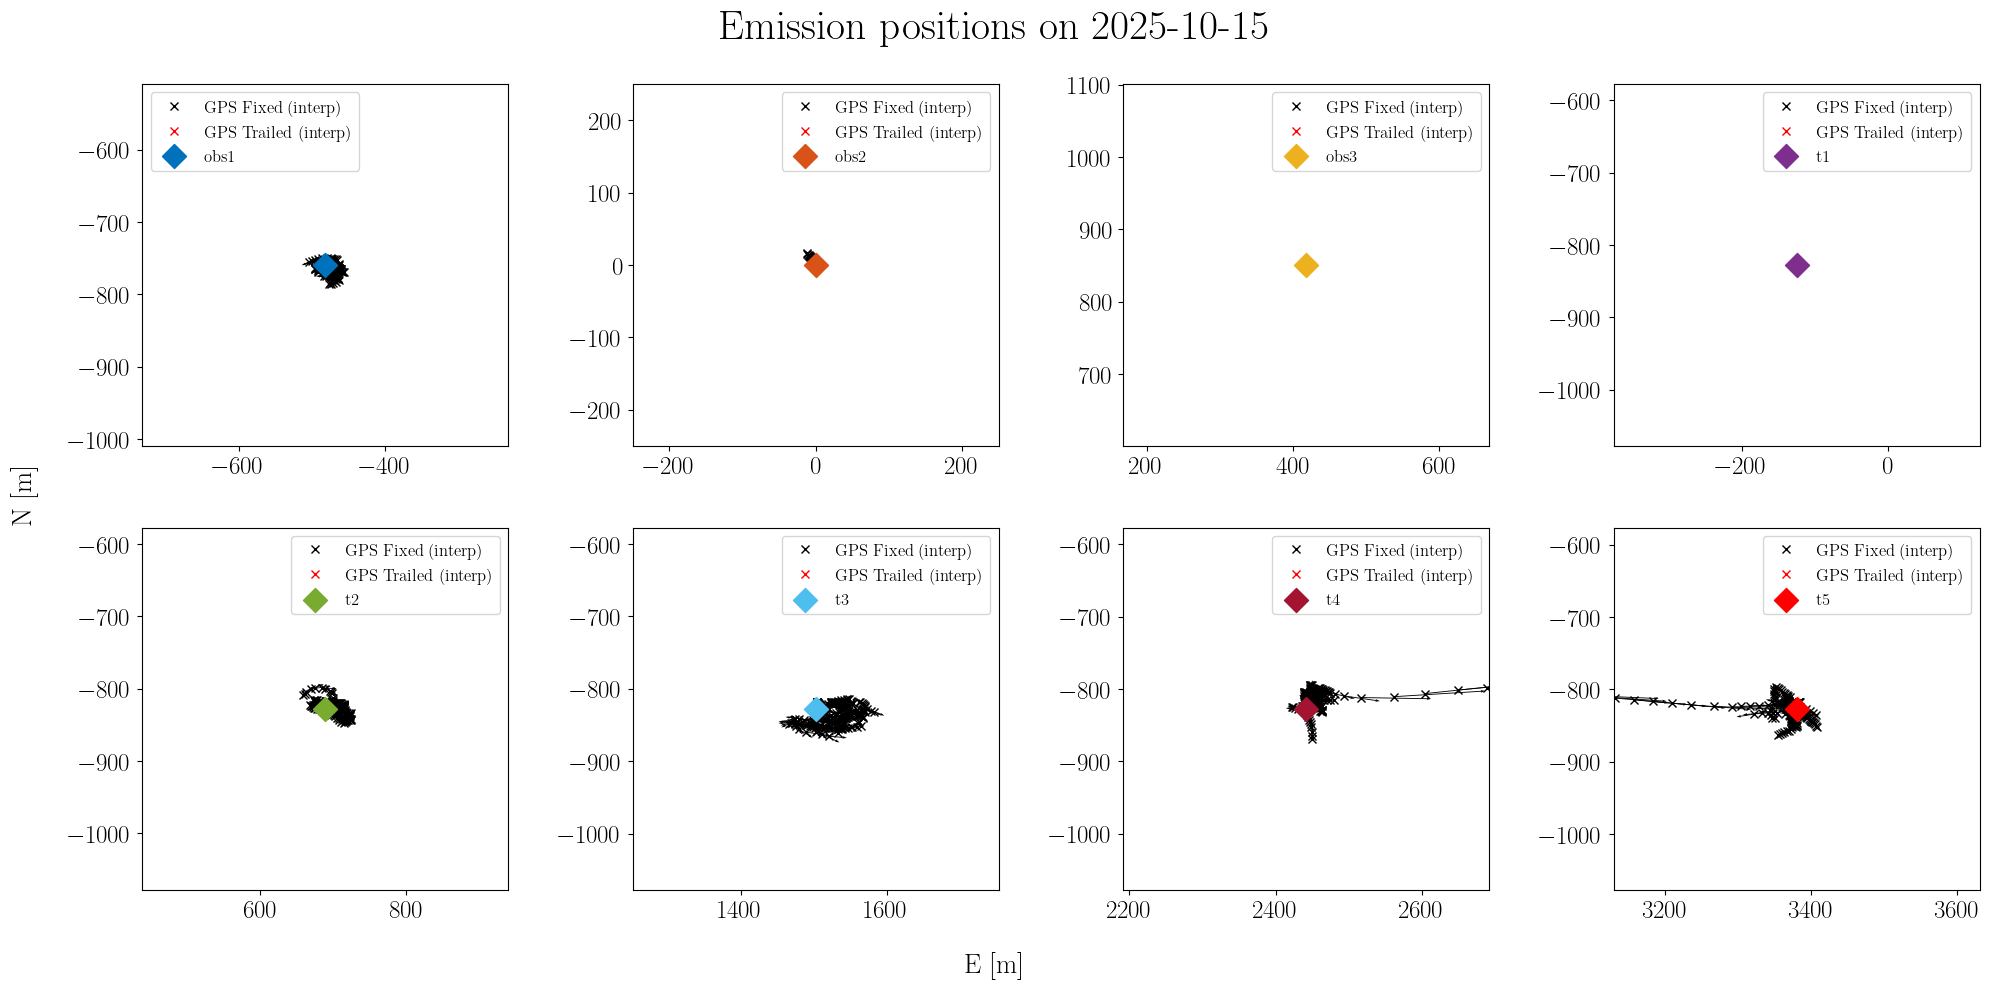

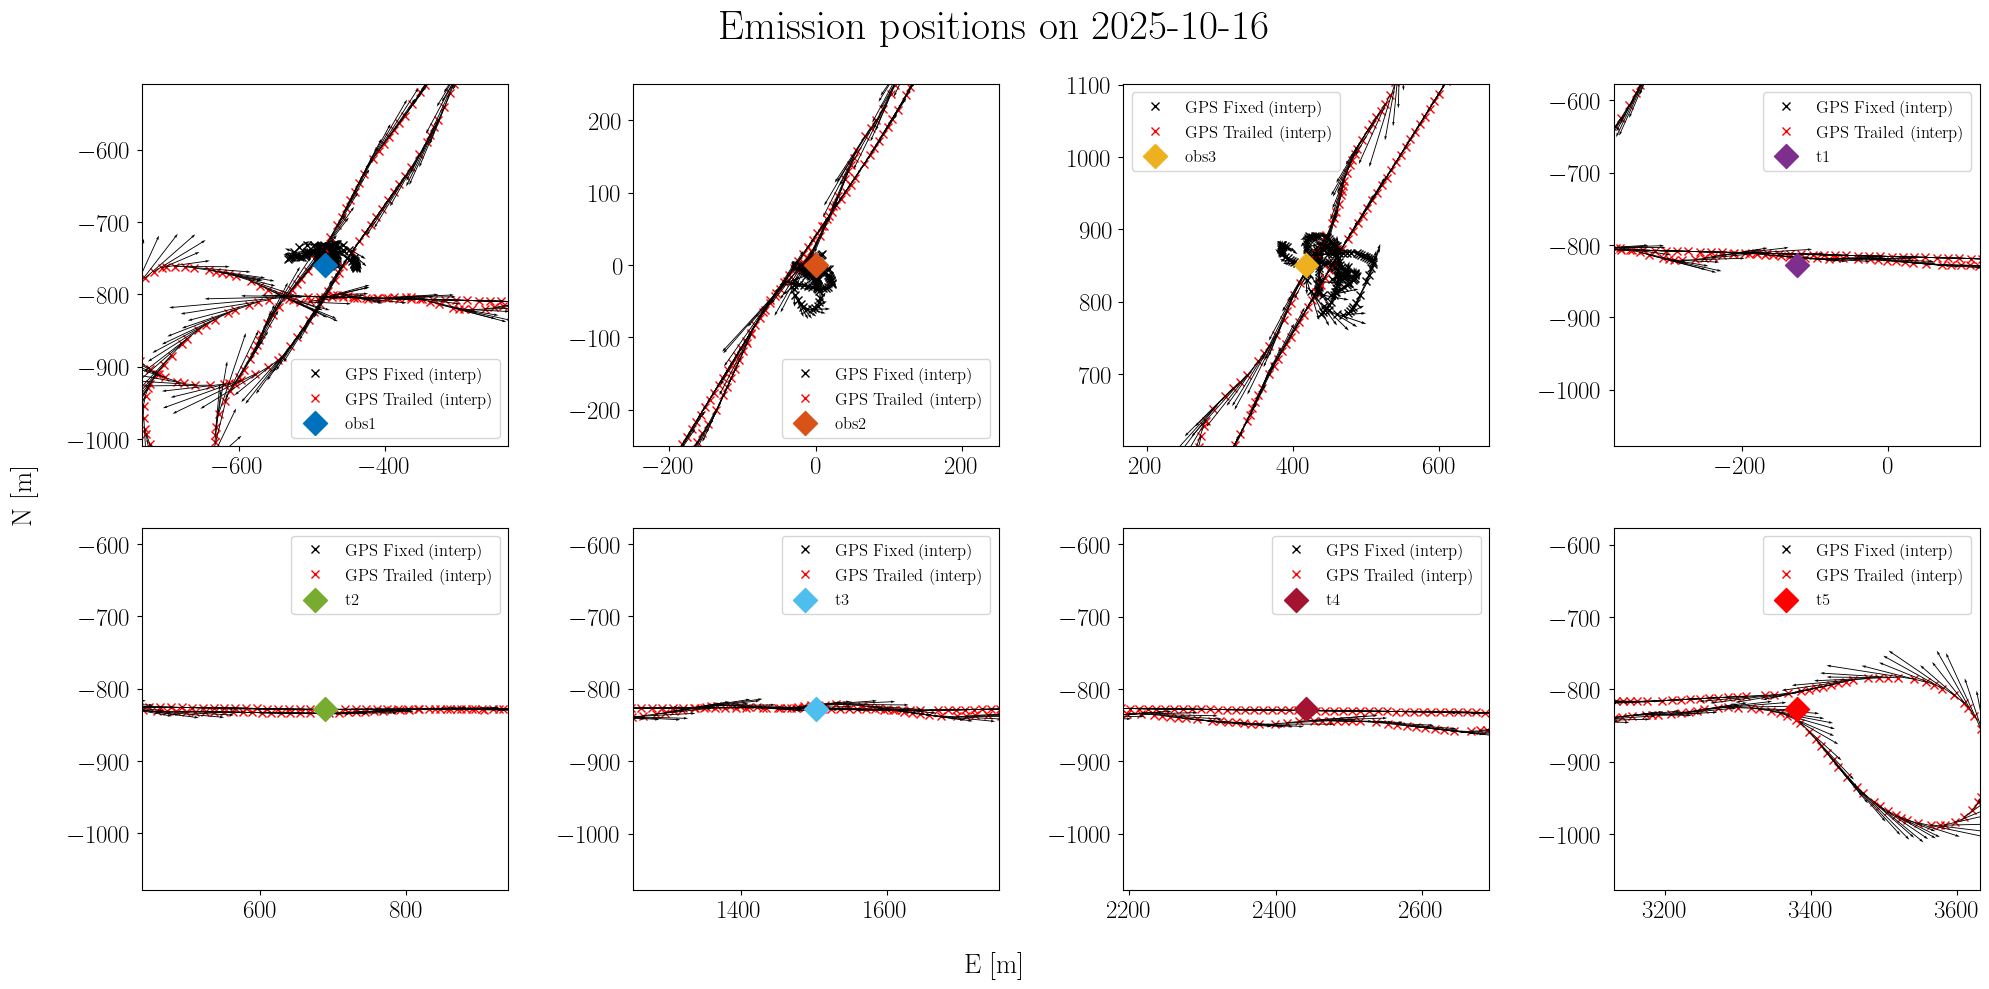

In [ ]:
# Analyse each day serapately

# Plot
pfig = PubFigure(ticks_fontsize=18, label_fontsize=20, legend_fontsize=12)
de = 500
dn = 500

pos_of_interest = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]

days = df["emission_datetime"].dt.date.unique()
for day in days:

    df_sel = df[df["emission_datetime"].dt.date == day]

    fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(20, 10), sharex=False, sharey=False)
    for ipos, pos in enumerate(pos_of_interest):
        i = ipos // 4
        j = ipos % 4
        ax = axs[i, j]

        # Choose color base on the type of emission (fixed or trailed)
        mask_trailed = df["src_pos_status"].str.fullmatch("trailed")
        mask_fixed = df["src_pos_status"].str.fullmatch("fixed")

        ax.plot(
            df_sel["emission_interp_e_gps"][mask_fixed],
            df_sel["emission_interp_n_gps"][mask_fixed],
            "x",
            label="GPS Fixed (interp)",
            color="k",
            zorder=1,
        )
        ax.plot(
            df_sel["emission_interp_e_gps"][mask_trailed],
            df_sel["emission_interp_n_gps"][mask_trailed],
            "x",
            label="GPS Trailed (interp)",
            color="r",
            zorder=2,
        )

        ax.quiver(
            df_sel["emission_interp_e_gps"][mask_fixed],
            df_sel["emission_interp_n_gps"][mask_fixed],
            df_sel["emission_interp_ve_gps"][mask_fixed],
            df_sel["emission_interp_vn_gps"][mask_fixed],
            zorder=3,
            # "x",
            # label="GPS Fixed (interp)",
            # color="k",
        )
        ax.quiver(
            df_sel["emission_interp_e_gps"][mask_trailed],
            df_sel["emission_interp_n_gps"][mask_trailed],
            df_sel["emission_interp_ve_gps"][mask_trailed],
            df_sel["emission_interp_vn_gps"][mask_trailed],
            zorder=4,
            scale=10,
            # "x",
            # label="GPS Trailed (interp)",
            # color="r",
        )

        e_pos = ds_gps.attrs[f"{pos}_e_apriori"]
        n_pos = ds_gps.attrs[f"{pos}_n_apriori"]
        for ik, k in enumerate(pos_of_interest):
            e_pos_k = ds_gps.attrs[f"{k}_e_apriori"]
            n_pos_k = ds_gps.attrs[f"{k}_n_apriori"]
            if np.abs(e_pos_k - e_pos) <= de/2 and np.abs(n_pos_k - n_pos) < dn/2:
                # print(f"Plotting {k} in pos {pos}: {e_pos_k}, {n_pos_k}")
                ax.scatter(
                    e_pos_k,
                    n_pos_k,
                    marker="D",
                    label=k,
                    zorder=10,
                    s=150,
                    color=color(ik),
                )
        ax.set_xlim([e_pos-de/2, e_pos+de/2])
        ax.set_ylim([n_pos-dn/2, n_pos+dn/2])

        ax.set_xlabel("")  
        ax.set_ylabel("")
        ax.legend()

    fig.supxlabel("E [m]")
    fig.supylabel("N [m]")

    fig.suptitle(f"Emission positions on {day.strftime('%Y-%m-%d')}")

    # # Save figure
    # fig_fpath = os.path.join(
    #     img_folder, "emission", f"emission_positions_{day.strftime('%Y_%m_%d')}.png"
    # )
    # plt.savefig(fig_fpath, dpi=300)

In [ ]:
# Save data
fpath = os.path.join(data_folder, "processed_emissions.nc")
ds = xr.Dataset.from_dataframe(df)
ds.to_netcdf(fpath)

# fpath = os.path.join(data_folder, "source_emissions_processed.csv")
# df.to_csv(fpath, index=False)

In [ ]:
# df.dtypes

In [ ]:
# df_dtypes = pd.DataFrame(df.dtypes, columns=["dtype"]).reset_index()
# fpath = os.path.join(data_folder, "source_emissions_processed_dtypes.csv")
# df_dtypes.to_csv(fpath, index=False)